In [1]:
from tqrb import TQRB_Experiment
from selene_sim import DepolarizingErrorModel, Stim
from pecos_selene import qsystem_model_alpha

In [ ]:
# select parameters and build experiment

qubits = [(0,1),(2,3),(4,5),(6,7),(8,9),(10,11),(12,13),(14,15)]
seq_lengths = [4, 100, 200, 400]
seq_reps = 10
filename = 'exp_TQRB_example.p'

exp = TQRB_Experiment(qubits, seq_lengths, seq_reps, filename=filename)
exp.options['measure_leaked'] = True
exp.options['barriers'] = False
exp.options['order_in_zones'] = True
#exp.options['parallel'] = False # if True, then same Clifford gets applied to each zone. Default is False

exp.add_settings()


In [ ]:
# or load an existing experiment

filename = 'exp_TQRB_example.p'
exp = TQRB_Experiment.load(filename)

In [4]:
# Setup error model

error_model = DepolarizingErrorModel(
    random_seed=1164,
    # single qubit gate error rate
    #p_1q=3e-5,
    # two qubit gate error rate
    p_2q=1e-3,
    # set state preparation and measurement error rates to 0
    p_meas=0,
    p_init=0,
)

In [3]:
# Hardware realistic device error model

error_model = qsystem_model_alpha(random_seed=2)

C:\Users\karl.mayer\AppData\Local\anaconda3\envs\guppy_env\Lib\site-packages\pecos_selene\error_models\named.py:35: UserWarning: 


* The crosstalk channels are implemented using a very naive model.

* Leakage and memory error are implemented as in H1/H2, but it is expectedthese will change significantly in Helios.

* The noise parameter values are rough estimates, using a combination of target values for Helios and values from H2's model. These have not been verified by benchmarking experiments on the device.

* Anduril (the component that decides ion transport) does not currently report accurate timing estimates. This affects the memory error.

  warnings.warn(msg)


In [4]:
# simulate experiment

shots = 100
simulator = Stim()

exp.sim(shots, error_model=error_model, simulator=simulator)

Simulating ...
1/15 circuits complete
2/15 circuits complete
3/15 circuits complete
4/15 circuits complete
5/15 circuits complete
6/15 circuits complete
7/15 circuits complete
8/15 circuits complete
9/15 circuits complete
10/15 circuits complete
11/15 circuits complete
12/15 circuits complete
13/15 circuits complete
14/15 circuits complete
15/15 circuits complete


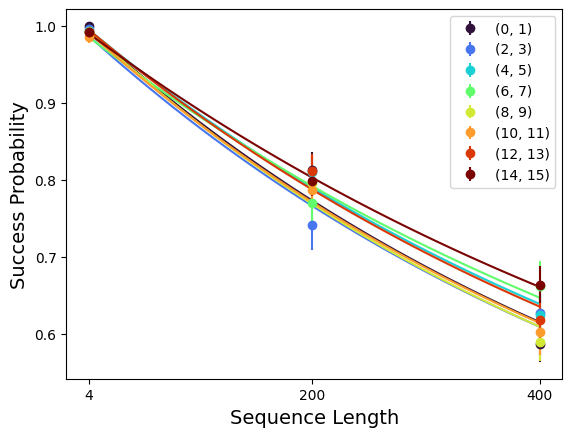

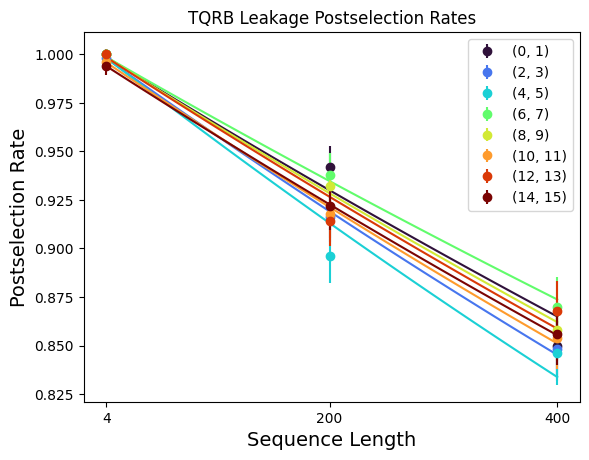

TQ Average Infidelities:
----------------------------------
qubits (0, 1): 0.00114 +/- 7e-05
qubits (2, 3): 0.00119 +/- 8e-05
qubits (4, 5): 0.00112 +/- 8e-05
qubits (6, 7): 0.001 +/- 0.0001
qubits (8, 9): 0.00117 +/- 7e-05
qubits (10, 11): 0.00116 +/- 8e-05
qubits (12, 13): 0.00109 +/- 7e-05
qubits (14, 15): 0.001 +/- 6e-05
----------------------------------
Zone Average Infidelity:  0.00111 +/- 3e-05

TQ Leakage Rates:
----------------------------------
qubits (0, 1): 0.00024 +/- 4e-05
qubits (2, 3): 0.00028 +/- 1e-05
qubits (4, 5): 0.0003 +/- 4e-05
qubits (6, 7): 0.00022 +/- 2e-05
qubits (8, 9): 0.00025 +/- 2e-05
qubits (10, 11): 0.00026 +/- 1e-05
qubits (12, 13): 0.00025 +/- 3e-05
qubits (14, 15): 0.00025 +/- 0.0
----------------------------------
Zone Average Leakage Rate: 0.00026 +/- 1e-05
Experiment saved! exp_TQRB_test.p


In [5]:
exp.analyze_results(precision=5, num_resamples=100)

In [ ]:
# submit experiment to Quantinuum hardware or emulator backend

# Choose domain and login to Nexus

import qnexus

# for submitting to QA only
#from qnexus.config import CONFIG
#CONFIG.domain = "qa.myqos.com"

qnexus.login_with_credentials()

✅ Successfully logged in as karl.mayer@quantinuum.com.


In [ ]:
# choose nexus project and setup quantinuum backend config

project = qnexus.projects.get_or_create(name='TQRB-example-project')
qnexus.context.set_active_project(project)

backend_config = qnexus.QuantinuumConfig(device_name='Helios-1', max_cost=1000000)

In [6]:
# submit experiment. Returns a qnexus ExecuteJobRef

shots = 100

execute_job_ref = exp.submit(shots, backend_config, shuffle=True)

Experiment saved! exp_TQRB_test.p


In [8]:
# inspect status of the execution job

qnexus.jobs.status(execute_job_ref)

JobStatus(status=<JobStatusEnum.COMPLETED: 'COMPLETED'>, message='The job is completed.', error_detail=None, completed_time=datetime.datetime(2026, 2, 13, 6, 5, 52, 702931, tzinfo=datetime.timezone.utc), queued_time=datetime.datetime(2026, 2, 12, 21, 39, 13, 44859, tzinfo=datetime.timezone.utc), submitted_time=datetime.datetime(2026, 2, 12, 21, 39, 13, 28124, tzinfo=datetime.timezone.utc), running_time=datetime.datetime(2026, 2, 12, 23, 25, 23, 489291, tzinfo=datetime.timezone.utc), cancelled_time=None, error_time=None, queue_position=None, cost=22114.56)

In [9]:
# retrieve results

exp.retrieve(execute_job_ref)

Unknown OpType in BackendInfo: `%`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `%`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `%`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `%`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `%`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `%`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `%`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `%`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `%`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `%`, will omit from BackendInfo. Consider 

Experiment saved! TQRB_Helios-1_exp_2026-02-12.p


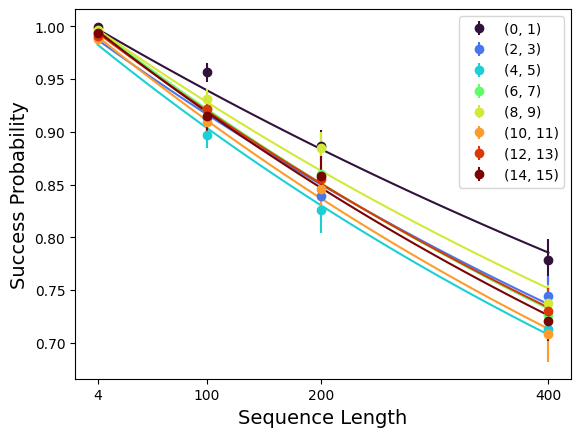

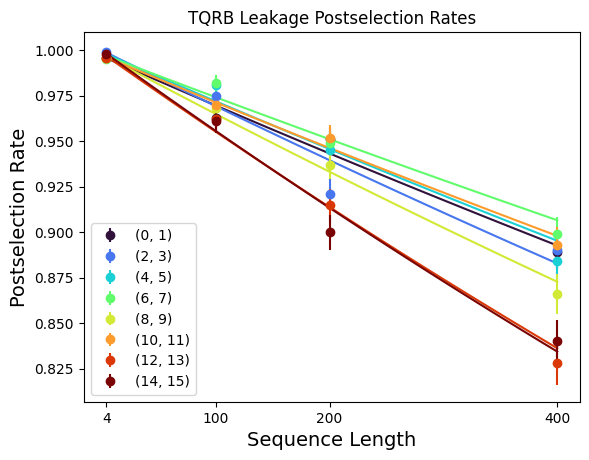

TQ Average Infidelities:
----------------------------------
qubits (0, 1): 0.0006 +/- 4e-05
qubits (2, 3): 0.00073 +/- 5e-05
qubits (4, 5): 0.00078 +/- 7e-05
qubits (6, 7): 0.00071 +/- 4e-05
qubits (8, 9): 0.00073 +/- 3e-05
qubits (10, 11): 0.00077 +/- 6e-05
qubits (12, 13): 0.00084 +/- 5e-05
qubits (14, 15): 0.00087 +/- 4e-05
----------------------------------
Zone Average Infidelity:  0.00075 +/- 2e-05

TQ Leakage Rates:
----------------------------------
qubits (0, 1): 0.00018 +/- 2e-05
qubits (2, 3): 0.00021 +/- 3e-05
qubits (4, 5): 0.00018 +/- 3e-05
qubits (6, 7): 0.00016 +/- 2e-05
qubits (8, 9): 0.00022 +/- 1e-05
qubits (10, 11): 0.00017 +/- 1e-05
qubits (12, 13): 0.0003 +/- 2e-05
qubits (14, 15): 0.0003 +/- 2e-05
----------------------------------
Zone Average Leakage Rate: 0.00022 +/- 1e-05
Experiment saved! TQRB_Helios-1_exp_2026-02-12.p


In [10]:
exp.analyze_results()

In [12]:
# save experiment object to working directory

exp.save()

Experiment saved! exp_TQRB_Helios-1_2026-02-12.p
